https://scikit-learn.org/stable/modules/tree.html

In [1]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd
import numpy as np

In [2]:
# Read CSV File
#df = pd.read_csv("d:/Dataset/accepted_2007_to_2018Q4.csv", low_memory=False)
df_dummies = pd.read_csv("d:/Dataset/LC_Cleaned_Data_dummies.csv", low_memory=False)

In [3]:
#Now that columns are encoded, split loan grades using a df dictionary 
grades = df_dummies['grade'].unique()
grade_dfs = {}
for grade in grades:
    grade_dfs[grade] = df_dummies[df_dummies['grade'] == grade].reset_index(drop=True)

In [5]:
models = {}
results = []
test_data = {}

grades = sorted(df_dummies['grade'].dropna().unique())

for grade in grades:

    # Split into target and predictors
    y = grade_dfs[grade]['loan_status_Charged Off']
    X = grade_dfs[grade].drop(
        columns=['loan_status_Charged Off', 'loan_status_Fully Paid', 'grade']
    )

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # Decision Tree Classifier
    tree_clf = DecisionTreeClassifier(
        criterion='gini',
        max_depth=5,
        min_samples_split=50,
        min_samples_leaf=25,
        class_weight='balanced',
        random_state=42
    )

    # Train model
    tree_clf.fit(X_train, y_train)

    # Save model and test data
    models[grade] = tree_clf

    test_data[grade] = {
        'X_test': X_test,
        'y_test': y_test
    }

    # Predictions
    y_pred = tree_clf.predict(X_test)
    y_prob = tree_clf.predict_proba(X_test)[:, 1]

    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_prob)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # 10-fold cross-validation
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    cv_scores = cross_val_score(
        tree_clf,
        X,
        y,
        cv=cv,
        scoring='roc_auc'
    )

    mean_cv_auc = cv_scores.mean()
    std_cv_auc = cv_scores.std()

    # Save results for comparison table
    results.append({
        'grade': grade,
        'n_rows': len(X),
        'accuracy': accuracy,
        'roc_auc': auc_score,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'cv_auc_mean': mean_cv_auc,
        'cv_auc_std': std_cv_auc,
        'true_negative': tn,
        'false_positive': fp,
        'false_negative': fn,
        'true_positive': tp
    })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Sort by grade
results_df = results_df.sort_values('grade')


In [6]:
# Round numeric values
results_df_rounded = results_df.round(4)

# Print comparison table
print(results_df_rounded)

# Output rounded results to CSV
results_df_rounded.to_csv("decision_tree_results_by_grade.csv", index=False)

  grade  n_rows  accuracy  roc_auc  precision  recall  f1_score  cv_auc_mean  \
0     A  235188    0.5382   0.6158     0.0816  0.6481    0.1450       0.6147   
1     B  393095    0.5692   0.5881     0.1666  0.5539    0.2562       0.5844   
2     C  382315    0.5393   0.5882     0.2665  0.6011    0.3693       0.5886   
3     D  201644    0.5630   0.6042     0.3663  0.6007    0.4551       0.5980   
4     E   94186    0.5958   0.5995     0.4737  0.4677    0.4707       0.6013   
5     F   32305    0.5581   0.5989     0.5080  0.6736    0.5792       0.5958   
6     G    9326    0.5681   0.5826     0.5687  0.5405    0.5542       0.5797   

   cv_auc_std  true_negative  false_positive  false_negative  true_positive  
0      0.0038          23473           20723            1000           1842  
1      0.0040          38915           29173            4698           5833  
2      0.0030          30919           28385            6844          10315  
3      0.0048          15346           12733   

In [12]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

import os

# Folder to save tree images
output_folder = "decision_tree_plots"
os.makedirs(output_folder, exist_ok=True)

for grade_to_plot in grades:

    tree_clf = models[grade_to_plot]

    X = grade_dfs[grade_to_plot].drop(
        columns=['loan_status_Charged Off', 'loan_status_Fully Paid', 'grade']
    )

    plt.figure(figsize=(28, 14))

    # These commented lines output the full tree
    #plot_tree(
    #    tree_clf,
    #    feature_names=X.columns,
    #    class_names=['Fully Paid', 'Charged Off'],
    #    filled=True,
    #    rounded=True,
    #    fontsize=8
    #)

    # These lines output a tree with limited depth
    plot_tree(
        tree_clf,
        feature_names=X.columns,
        class_names=['Fully Paid', 'Charged Off'],
        filled=True,
        rounded=True,
        fontsize=8,
        max_depth=3
    )

    plt.title(f"Decision Tree for Grade {grade_to_plot}", fontsize=18)

    # Save image
    filename = f"decision_tree_grade_{grade_to_plot}.png"
    filepath = os.path.join(output_folder, filename)

    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved: {filepath}")

Saved: decision_tree_plots\decision_tree_grade_A.png
Saved: decision_tree_plots\decision_tree_grade_B.png
Saved: decision_tree_plots\decision_tree_grade_C.png
Saved: decision_tree_plots\decision_tree_grade_D.png
Saved: decision_tree_plots\decision_tree_grade_E.png
Saved: decision_tree_plots\decision_tree_grade_F.png
Saved: decision_tree_plots\decision_tree_grade_G.png


In [8]:
from sklearn.tree import export_text

for grade, tree_clf in models.items():

    X = grade_dfs[grade].drop(
        columns=['loan_status_Charged Off', 'loan_status_Fully Paid', 'grade']
    )

    tree_rules = export_text(
        tree_clf,
        feature_names=list(X.columns),
        max_depth=5
    )

    print(f"\n================ Grade {grade} Tree Rules ================\n")
    print(tree_rules)


================ Grade A Tree Rules ================

|--- int_rate <= 6.90
|   |--- fico_range_low <= 717.50
|   |   |--- avg_cur_bal <= 17984.50
|   |   |   |--- dti <= 19.95
|   |   |   |   |--- inq_last_6mths <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- inq_last_6mths >  0.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- dti >  19.95
|   |   |   |   |--- avg_cur_bal <= 2510.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- avg_cur_bal >  2510.00
|   |   |   |   |   |--- class: 1
|   |   |--- avg_cur_bal >  17984.50
|   |   |   |--- inq_last_6mths <= 2.50
|   |   |   |   |--- avg_cur_bal <= 21713.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- avg_cur_bal >  21713.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- inq_last_6mths >  2.50
|   |   |   |   |--- loan_amnt <= 15500.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- loan_amnt >  15500.00
|   |   |   |   |   |--- class: 1
|   |--- fico_range_low >  717.50
|   |   |--- avg_

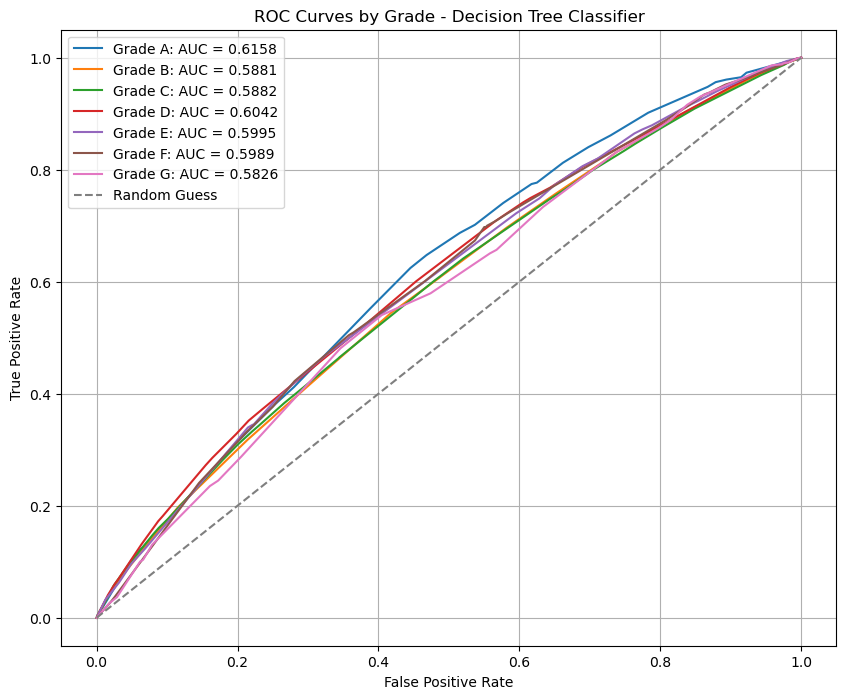

In [9]:
plt.figure(figsize=(10, 8))

for grade in sorted(models.keys()):

    tree_clf = models[grade]

    X_test = test_data[grade]['X_test']
    y_test = test_data[grade]['y_test']

    # Predicted probabilities for Charged Off/default class
    y_prob = tree_clf.predict_proba(X_test)[:, 1]

    # ROC curve values
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    # AUC score
    auc_score = roc_auc_score(y_test, y_prob)

    # Plot curve
    plt.plot(fpr, tpr, label=f"Grade {grade}: AUC = {auc_score:.4f}")

# Random guess line
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves by Grade - Decision Tree Classifier")
plt.legend()
plt.grid(True)
plt.show()